# PHẦN 1: PHƯƠNG PHÁP ĐẾM CHÍNH XÁC (EXACT COUNTING VỚI PYTHON SET)
## Chuyên đề Xử Lý Dữ Liệu Lớn - Giảng viên: Trần Thị Nhi

### 1. Cơ sở lý thuyết
- **Mục tiêu:** Xác định chính xác số lượng phần tử duy nhất (Cardinality / Zeroth Frequency Moment $F_0$) trong luồng dữ liệu truy cập máy chủ (Server Access Logs).
- **Cơ chế:** Sử dụng cấu trúc dữ liệu Tập hợp (`set()` trong Python) được cài đặt dựa trên Bảng băm (Hash Table).
- **Đặc tính kỹ thuật:**
  - **Thời gian:** $O(1)$ cho mỗi thao tác thêm phần tử `set.add(x)`.
  - **Bộ nhớ:** $O(n)$ với $n$ là số lượng phần tử duy nhất. Toàn bộ các chuỗi ký tự IP phải được lưu trữ trong RAM.
  - **Hạn chế trong Big Data:** Khi số lượng phần tử đạt hàng trăm triệu tới hàng tỷ, RAM hệ thống sẽ bị quá tải (Out of Memory - OOM).
- **Vai trò:** Đóng vai trò là **Ground Truth (Giá trị chuẩn $100\%$)** để đối chứng thời gian, mức tiêu thụ bộ nhớ và sai số của các thuật toán xác suất.

In [1]:
# 0. Tự động kiểm tra và Mount Google Drive (chỉ kích hoạt khi chạy trên Google Colab)
try:
    from google.colab import drive
    import os
    if not os.path.exists('/content/drive'):
        print("Đang kết nối tới Google Drive...")
        drive.mount('/content/drive')
    else:
        print("Google Drive đã được kết nối sẵn!")
except ImportError:
    print("Đang chạy trên môi trường Local (không phải Google Colab), bỏ qua mount Drive.")

Mounted at /content/drive


In [2]:
# 1. Khởi tạo và nạp các thư viện cần thiết
import os
import sys
import time
import json
import tracemalloc
import matplotlib.pyplot as plt

# Cấu hình font chữ và hiển thị đồ thị
plt.rcParams['figure.figsize'] = (12, 5)
print("Đã nạp xong thư viện thành công!")

Đã nạp xong thư viện thành công!


In [3]:
# 2. Cấu hình đường dẫn dữ liệu (Hỗ trợ cả Local và Google Colab)
def get_log_file_path():
    candidates = [
        "accessLog/access.log",
        "/content/drive/MyDrive/accessLog/access.log",
        "../accessLog/access.log",
        "access.log"
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    return "accessLog/access.log"  # Mặc định

LOG_FILE = get_log_file_path()
print(f"Đường dẫn file log được cấu hình: {LOG_FILE}")

Đường dẫn file log được cấu hình: /content/drive/MyDrive/accessLog/access.log


In [4]:
# 3. Hàm đọc luồng dữ liệu (Data Stream Generator)
def stream_log_file(file_path):
    """
    Đọc file log thật theo cơ chế streaming (generator).
    Trích xuất địa chỉ IP ở đầu mỗi dòng mà không nạp toàn bộ file vào RAM.
    """
    if not os.path.exists(file_path):
        print(f"[CẢNH BÁO] Không tìm thấy file: {file_path}")
        return

    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if line:
                # Trích xuất IP (phần tử đầu tiên trước dấu cách)
                ip = line.split(' ', 1)[0]
                yield ip

In [5]:
# 4. Hàm thực nghiệm đếm chính xác bằng Set
def run_set_experiment(log_file_path, sample_step=50000, max_lines=None):
    exact_set = set()
    stream_counts = []
    unique_history = []
    ram_history_mb = []

    print("="*70)
    print("BẮT ĐẦU THỰC NGHIỆM ĐẾM CHÍNH XÁC (SET)")
    print(f"File: {log_file_path} | Sample step: {sample_step:,} dòng")
    print("="*70)

    tracemalloc.start()
    start_time = time.time()
    total_processed = 0

    for ip in stream_log_file(log_file_path):
        total_processed += 1
        exact_set.add(ip)

        if total_processed % sample_step == 0:
            curr_unique = len(exact_set)
            current_ram, _ = tracemalloc.get_traced_memory()
            current_ram_mb = current_ram / (1024 * 1024)

            stream_counts.append(total_processed)
            unique_history.append(curr_unique)
            ram_history_mb.append(round(current_ram_mb, 2))

            print(f"Dòng đã duyệt: {total_processed:>10,} | IP duy nhất: {curr_unique:>8,} | RAM: {current_ram_mb:>6.2f} MB")

        if max_lines and total_processed >= max_lines:
            break

    elapsed_time = time.time() - start_time
    _, peak_ram = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    exact_final = len(exact_set)
    set_container_bytes = sys.getsizeof(exact_set)
    set_elements_bytes = sum(sys.getsizeof(s) for s in exact_set)
    total_set_bytes = set_container_bytes + set_elements_bytes

    print("\n" + "="*70)
    print("KẾT QUẢ TỔNG KẾT (PHƯƠNG PHÁP SET):")
    print(f"- Tổng số dòng log đã quét:            {total_processed:,}")
    print(f"- Số lượng IP duy nhất (Chính xác 100%): {exact_final:,}")
    print(f"- Thời gian thực thi:                  {elapsed_time:.2f} giây")
    print(f"- Bảng băm container:                  {set_container_bytes / (1024*1024):.3f} MB ({set_container_bytes:,} bytes)")
    print(f"- Dung lượng các chuỗi IP trong RAM:   {set_elements_bytes / (1024*1024):.3f} MB ({set_elements_bytes:,} bytes)")
    print(f"- Tổng RAM thực tế cấu trúc Set chiếm: {total_set_bytes / (1024*1024):.3f} MB ({total_set_bytes:,} bytes)")
    print(f"- Peak RAM hệ thống ghi nhận:          {peak_ram / (1024*1024):.3f} MB")
    print("="*70)

    # Lưu kết quả sang results/set_metrics.json để phục vụ so sánh ở Notebook 4
    os.makedirs('results', exist_ok=True)
    results_data = {
        "method": "Set (Exact)",
        "total_processed": total_processed,
        "exact_final": exact_final,
        "elapsed_time": round(elapsed_time, 2),
        "total_set_bytes": total_set_bytes,
        "peak_ram_bytes": peak_ram,
        "history_steps": stream_counts,
        "history_unique": unique_history,
        "history_ram_mb": ram_history_mb
    }
    with open('results/set_metrics.json', 'w', encoding='utf-8') as f:
        json.dump(results_data, f, indent=2, ensure_ascii=False)
    print("-> Đã lưu kết quả thành công vào 'results/set_metrics.json'!")

    return stream_counts, unique_history, ram_history_mb

In [6]:
# 5. Chạy thực nghiệm
# Bạn có thể điều chỉnh sample_step hoặc max_lines (ví dụ max_lines=200000 để kiểm thử nhanh)
steps, uniques, rams = run_set_experiment(LOG_FILE, sample_step=50000)

BẮT ĐẦU THỰC NGHIỆM ĐẾM CHÍNH XÁC (SET)
File: /content/drive/MyDrive/accessLog/access.log | Sample step: 50,000 dòng
Dòng đã duyệt:     50,000 | IP duy nhất:    2,179 | RAM:   0.31 MB
Dòng đã duyệt:    100,000 | IP duy nhất:    3,987 | RAM:   0.40 MB
Dòng đã duyệt:    150,000 | IP duy nhất:    5,346 | RAM:   0.85 MB
Dòng đã duyệt:    200,000 | IP duy nhất:    6,510 | RAM:   0.91 MB
Dòng đã duyệt:    250,000 | IP duy nhất:    7,616 | RAM:   0.96 MB
Dòng đã duyệt:    300,000 | IP duy nhất:    8,694 | RAM:   1.02 MB
Dòng đã duyệt:    350,000 | IP duy nhất:    9,685 | RAM:   1.07 MB
Dòng đã duyệt:    400,000 | IP duy nhất:   10,653 | RAM:   1.12 MB
Dòng đã duyệt:    450,000 | IP duy nhất:   11,676 | RAM:   1.17 MB
Dòng đã duyệt:    500,000 | IP duy nhất:   12,669 | RAM:   1.22 MB
Dòng đã duyệt:    550,000 | IP duy nhất:   13,605 | RAM:   1.27 MB
Dòng đã duyệt:    600,000 | IP duy nhất:   14,656 | RAM:   1.33 MB
Dòng đã duyệt:    650,000 | IP duy nhất:   15,618 | RAM:   1.38 MB
Dòng đã duyệ

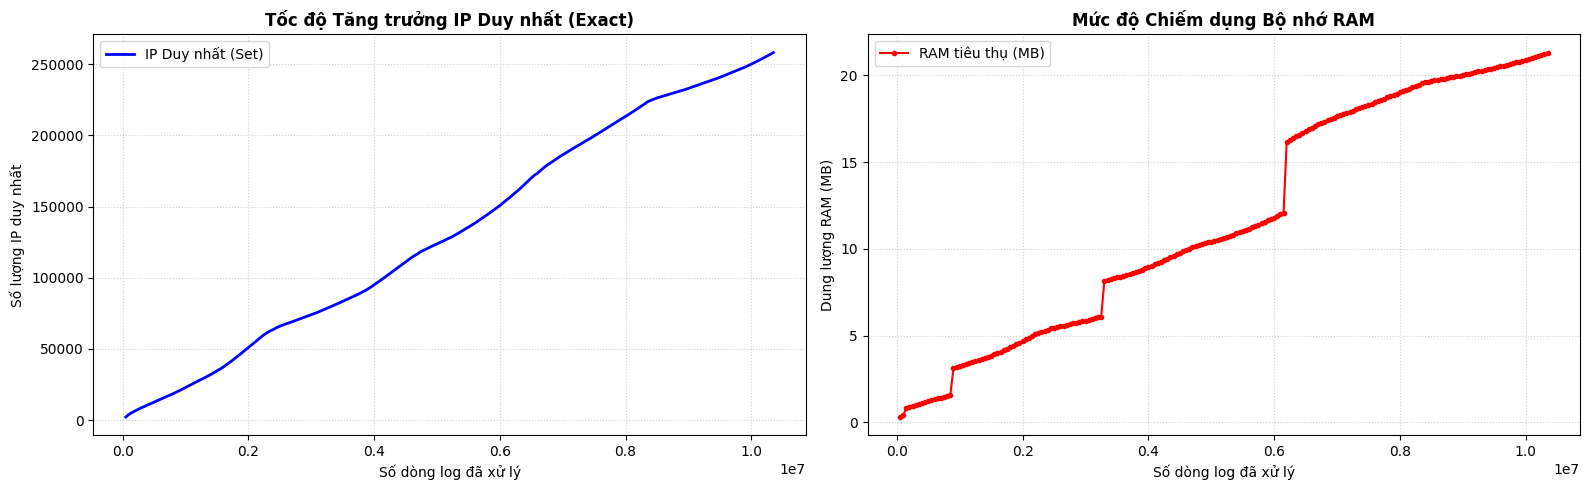

In [7]:
# 6. Trực quan hóa kết quả phương pháp Set
if steps:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # Đồ thị 1: Tăng trưởng IP duy nhất
    ax1.plot(steps, uniques, 'b-', linewidth=2, label='IP Duy nhất (Set)')
    ax1.set_title('Tốc độ Tăng trưởng IP Duy nhất (Exact)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Số dòng log đã xử lý')
    ax1.set_ylabel('Số lượng IP duy nhất')
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend()

    # Đồ thị 2: Tiêu thụ RAM thực tế theo thời gian
    ax2.plot(steps, rams, 'r-o', markersize=3, label='RAM tiêu thụ (MB)')
    ax2.set_title('Mức độ Chiếm dụng Bộ nhớ RAM', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Số dòng log đã xử lý')
    ax2.set_ylabel('Dung lượng RAM (MB)')
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend()

    plt.tight_layout()
    plt.show()

### 7. Nhận xét và Kết luận về phương pháp Set
- **Ưu điểm:** Độ chính xác đạt $100\%$ tuyệt đối, không có sai số xác suất.
- **Nhược điểm chí tử:** Dung lượng bộ nhớ tăng tuyến tính theo số phần tử duy nhất. Khi tập dữ liệu lên đến hàng trăm triệu bản ghi hoặc chạy liên tục trên hệ thống streaming (24/7), bộ nhớ RAM sẽ bị cạn kiệt, dẫn đến lỗi hệ thống.
- **Kết luận:** Phương pháp này chỉ phù hợp khi quy mô dữ liệu nhỏ hoặc dùng làm tập dữ liệu chuẩn để kiểm thử thuật toán xấp xỉ.